In [40]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

warnings.filterwarnings('ignore')

df=pd.read_csv("analitic_avito_dataset_50_pages.csv")

df['price']=pd.to_numeric(df['price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['space']=pd.to_numeric(df['space'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['area_price']=pd.to_numeric(df['area_price'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df['time_to_metro']=pd.to_numeric(df['time_to_metro'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df=df.dropna(subset=['price', 'space', 'area_price', 'time_to_metro'])
print(df.shape)
print(df.dtypes)

(1917, 9)
type               str
space            int64
price            int64
area_price       int64
address            str
metro              str
time_to_metro    int64
date               str
source             str
dtype: object


In [41]:
def metro_category(x):
    if x<=10:
        return "Близко к метро"
    elif x<=20:
        return "Средне"
    else:
        return "Далеко"
    
df["metro_group"]=df["time_to_metro"].apply(metro_category)

df["metro_group"].value_counts()

metro_group
Средне            651
Близко к метро    638
Далеко            628
Name: count, dtype: int64

In [42]:
top_type=df["type"].value_counts().head(4).index
df_anova=df[df["type"].isin(top_type)].copy()

df_anova=df_anova.dropna(subset=["area_price", "type", "metro_group"])


In [43]:
group_stats=df_anova.groupby("type")["area_price"].agg(
    n="count",
    mean="mean",
    std="std"
)
group_stats["sem"]=group_stats["std"]/np.sqrt(group_stats["n"])
group_stats

,n,mean,std,sem
type,,,,
1-к. квартира,570,259763.498246,69883.925871,2927.115548
2-к. квартира,524,250182.841603,74459.833817,3252.792943
3-к. квартира,315,243282.050794,125080.553800,7047.490815
Квартира-студия,278,273805.456835,54015.350988,3239.625468


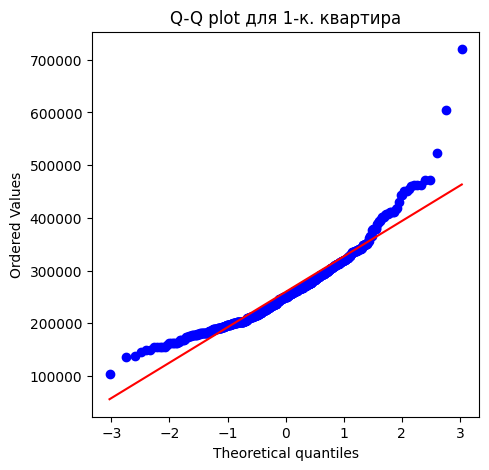

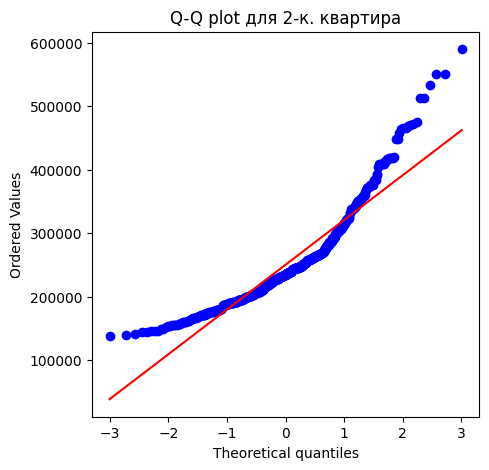

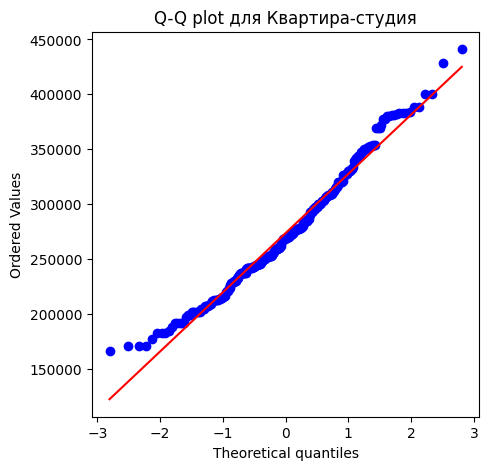

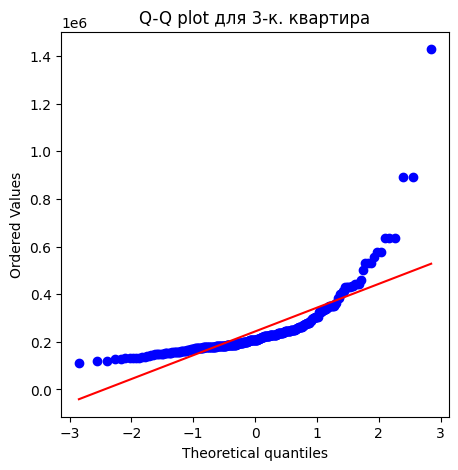

In [44]:
for group in df_anova["type"].unique():
    data=df_anova[df_anova["type"]==group]["area_price"]

    plt.figure(figsize=(5,5))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q plot для {group}")
    plt.show()

In [45]:
for group in df_anova["type"].unique():
    data=df_anova[df_anova["type"]==group]["area_price"]
    stat, p =stats.shapiro(data.sample(min(len(data), 5000), random_state=42))
    
    print(group)
    print("W =", stat)
    print("p-value =", p)
    print()

1-к. квартира
W = 0.9190181247150732
p-value = 6.34074434899717e-17

2-к. квартира
W = 0.889357633149705
p-value = 6.016904563898566e-19

Квартира-студия
W = 0.9795591902131666
p-value = 0.0005130060138959719

3-к. квартира
W = 0.6382477992319224
p-value = 2.735929640098548e-25



In [46]:
groups=[df_anova[df_anova["type"]==group]["area_price"] for group in df_anova["type"].unique()]

levene_stat, levene_p=stats.levene(*groups)

print("Levene statistic =", levene_stat)
print("p-value =", levene_p)

Levene statistic = 7.623306094361194
p-value = 4.613091258437746e-05


<Figure size 1000x600 with 0 Axes>

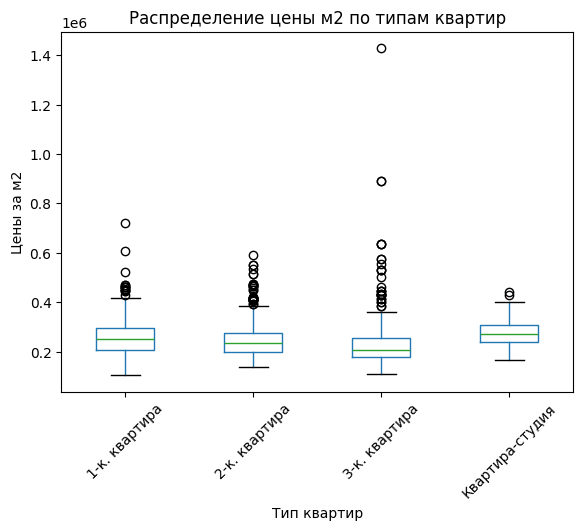

In [47]:
plt.figure(figsize=(10,6))
df_anova.boxplot(column="area_price", by="type", grid=False)
plt.title("Распределение цены м2 по типам квартир")
plt.suptitle("")
plt.xlabel("Тип квартир")
plt.ylabel("Цены за м2")
plt.xticks(rotation=45)
plt.show()

In [48]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model=ols("area_price ~ C(type)", data=df_anova).fit()
anova_table=sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(type),1.648899e+11,3.0,8.114829,0.000023
Residual,1.139928e+13,1683.0,NaN,NaN


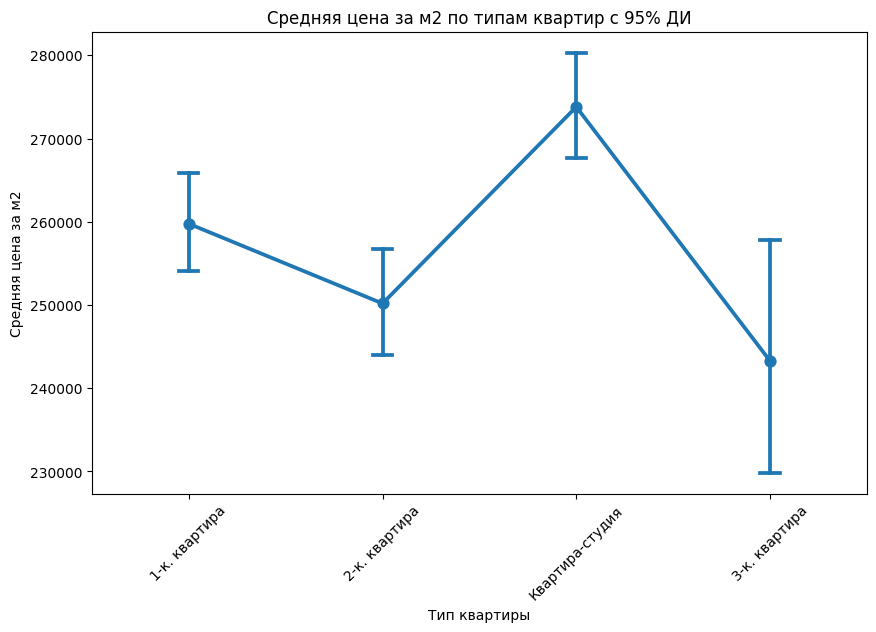

In [49]:
plt.figure(figsize=(10,6))
sns.pointplot(data=df_anova, x="type", y="area_price", errorbar=("ci", 95), capsize=0.1)

plt.title("Средняя цена за м2 по типам квартир с 95% ДИ")
plt.xlabel("Тип квартиры")
plt.ylabel("Средняя цена за м2")
plt.xticks(rotation=45)
plt.show()

In [50]:
tukey=pairwise_tukeyhsd(
    endog=df_anova["area_price"],
    groups=df_anova["type"],
    alpha=0.05
)
print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
    group1         group2       meandiff  p-adj     lower      upper    reject
------------------------------------------------------------------------------
1-к. квартира   2-к. квартира  -9580.6566 0.2185 -22389.3741  3228.0608  False
1-к. квартира   3-к. квартира -16481.4475 0.0228 -31340.0849   -1622.81   True
1-к. квартира Квартира-студия  14041.9586 0.0912  -1440.4368  29524.354  False
2-к. квартира   3-к. квартира  -6900.7908 0.6421 -21989.7789  8188.1972  False
2-к. квартира Квартира-студия  23622.6152 0.0007   7919.0162 39326.2143   True
3-к. квартира Квартира-студия   30523.406    0.0  13107.3535 47939.4586   True
------------------------------------------------------------------------------


In [51]:
kw_stat, kw_p=stats.kruskal(*groups)
print("H =", kw_stat)
print("p-value =", kw_p)

H = 113.71342882591715
p-value = 1.7420421694399372e-24


In [53]:
import scikit_posthocs as sp
dunn=sp.posthoc_dunn(
    df_anova,
    val_col="area_price",
    group_col="type",
    p_adjust="holm"
)
dunn

,1-к. квартира,2-к. квартира,3-к. квартира,Квартира-студия
1-к. квартира,1.000000e+00,8.428130e-04,4.463597e-13,5.157935e-05
2-к. квартира,8.428130e-04,1.000000e+00,1.961290e-05,2.542360e-11
3-к. квартира,4.463597e-13,1.961290e-05,1.000000e+00,3.259696e-23
Квартира-студия,5.157935e-05,2.542360e-11,3.259696e-23,1.000000e+00


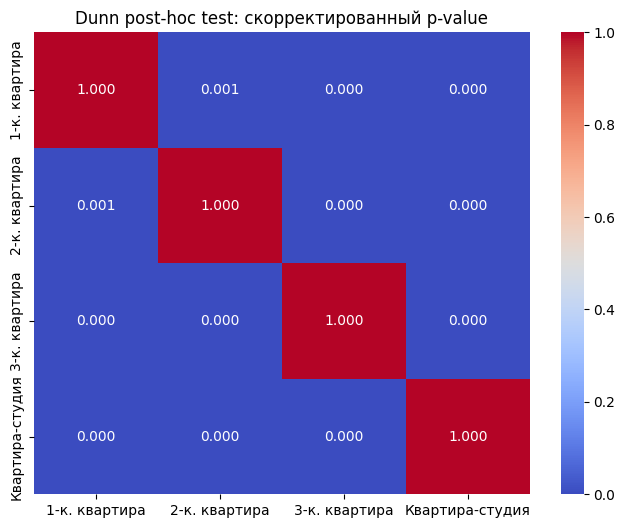

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(dunn, annot=True, cmap="coolwarm", fmt=".3f")
plt.title("Dunn post-hoc test: скорректированный p-value")
plt.show()

In [55]:
cell_count=pd.crosstab(df_anova["type"], df_anova["metro_group"])
cell_count

metro_group,Близко к метро,Далеко,Средне
type,,,
1-к. квартира,116,248,206
2-к. квартира,165,162,197
3-к. квартира,116,81,118
Квартира-студия,123,97,58


In [56]:
two_way_means=df_anova.groupby(["type", "metro_group"])["area_price"].mean().reset_index()
two_way_means

,type,metro_group,area_price
0,1-к. квартира,Близко к метро,272766.965517
1,1-к. квартира,Далеко,237534.310484
2,1-к. квартира,Средне,279202.509709
3,2-к. квартира,Близко к метро,269713.896970
4,2-к. квартира,Далеко,224716.728395
5,2-к. квартира,Средне,254766.020305
6,3-к. квартира,Близко к метро,277461.724138
7,3-к. квартира,Далеко,196017.086420
8,3-к. квартира,Средне,242126.288136
9,Квартира-студия,Близко к метро,283258.227642


In [57]:
model2=ols("area_price ~ C(type) + C(metro_group) + C(type):C(metro_group)", data=df_anova).fit()

anova_table2=sm.stats.anova_lm(model2, typ=2)
anova_table2

,sum_sq,df,F,PR(>F)
C(type),2.234490e+11,3.0,11.731993,1.315779e-07
C(metro_group),6.557096e+11,2.0,51.641181,1.725046e-22
C(type):C(metro_group),1.094833e+11,6.0,2.874161,8.653398e-03
Residual,1.063409e+13,1675.0,NaN,NaN


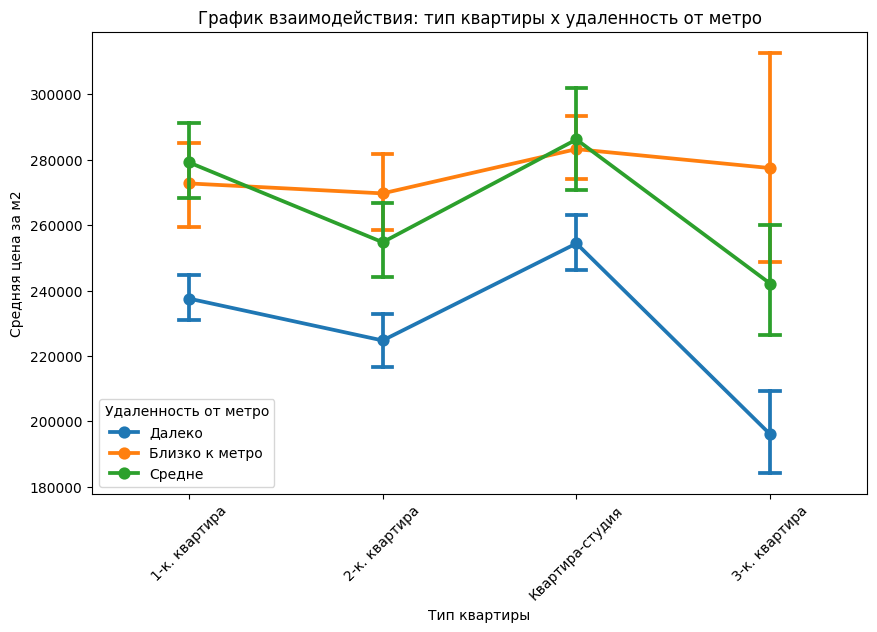

In [59]:
plt.figure(figsize=(10, 6))
sns.pointplot(
    data=df_anova,
    x="type",
    y="area_price",
    hue="metro_group",
    errorbar=("ci", 95),
    capsize=0.1
)
plt.title("График взаимодействия: тип квартиры х удаленность от метро")
plt.xlabel("Тип квартиры")
plt.ylabel("Средняя цена за м2")
plt.xticks(rotation=45)
plt.legend(title="Удаленность от метро")
plt.show()

In [60]:
ss_factor=anova_table.loc["C(type)", "sum_sq"]
ss_total=anova_table["sum_sq"].sum()

eta_squared=ss_factor/ss_total

eta_squared

np.float64(0.014258685511034581)